---



---

# **JOBSHEET 3 - PERBAIKAN CITRA DALAM DOMAIN SPASIAL**
###Penugasan Nomor 3, 4, dan 5
---



---

NAMA : Muhammad Eka Sobirin

NIM : 3.34.23.2.14

Mata Kuliah : Pengolahan Citra

Dosen Pengampu : Ir. Prayitno, S.ST., M.T., Ph.D.



---



---



##**Penugasan Nomor 3**
Soal :

3.	Eksperimen Transformasi Intensitas Lain: Cobalah menerapkan transformasi kurva lain selain citra negatif, misalnya transformasi logaritmik atau transformasi gamma. Gunakan citra grayscale yang berbeda (contoh: skimage.data.camera() vs skimage.data.astronaut() yang diubah ke grayscale). Amati perbedaan yang dihasilkan terhadap citra asli. Jelaskan bagaimana parameter (konstanta c atau gamma) memengaruhi hasil citra.
https://scikit-image.org/docs/stable/api/skimage.exposure.html#skimage.exposure.adjust_gamma


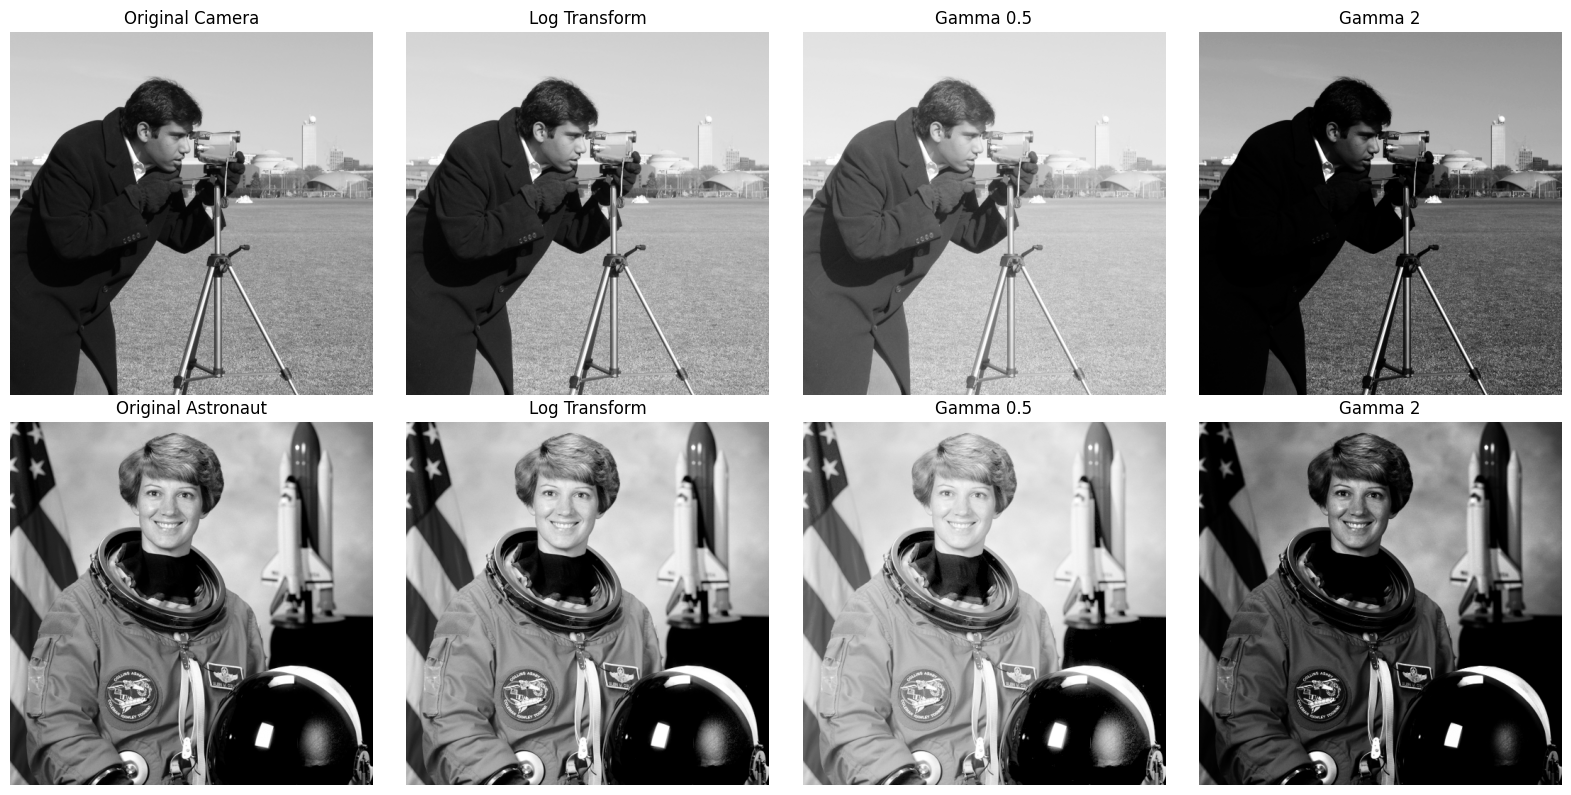

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, color, exposure, img_as_float

# =========================
# 1. Ambil gambar grayscale
# =========================
image1 = img_as_float(data.camera())  # sudah grayscale

image2_rgb = data.astronaut()
image2 = img_as_float(color.rgb2gray(image2_rgb))  # ubah ke grayscale

# =========================
# 2. Transformasi Logaritmik
# =========================
log_image1 = exposure.adjust_log(image1, gain=1)
log_image2 = exposure.adjust_log(image2, gain=1)

# =========================
# 3. Transformasi Gamma
# =========================
gamma_05_img1 = exposure.adjust_gamma(image1, gamma=0.5)
gamma_2_img1 = exposure.adjust_gamma(image1, gamma=2)

gamma_05_img2 = exposure.adjust_gamma(image2, gamma=0.5)
gamma_2_img2 = exposure.adjust_gamma(image2, gamma=2)

# =========================
# 4. Visualisasi
# =========================
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

# --- Gambar 1 (camera) ---
axes[0,0].imshow(image1, cmap='gray')
axes[0,0].set_title("Original Camera")
axes[0,0].axis('off')

axes[0,1].imshow(log_image1, cmap='gray')
axes[0,1].set_title("Log Transform")
axes[0,1].axis('off')

axes[0,2].imshow(gamma_05_img1, cmap='gray')
axes[0,2].set_title("Gamma 0.5")
axes[0,2].axis('off')

axes[0,3].imshow(gamma_2_img1, cmap='gray')
axes[0,3].set_title("Gamma 2")
axes[0,3].axis('off')

# --- Gambar 2 (astronaut grayscale) ---
axes[1,0].imshow(image2, cmap='gray')
axes[1,0].set_title("Original Astronaut")
axes[1,0].axis('off')

axes[1,1].imshow(log_image2, cmap='gray')
axes[1,1].set_title("Log Transform")
axes[1,1].axis('off')

axes[1,2].imshow(gamma_05_img2, cmap='gray')
axes[1,2].set_title("Gamma 0.5")
axes[1,2].axis('off')

axes[1,3].imshow(gamma_2_img2, cmap='gray')
axes[1,3].set_title("Gamma 2")
axes[1,3].axis('off')

plt.tight_layout()
plt.show()

##**Penugasan Nomor 4**
Soal :

4.	Perbandingan Metode Peningkatan Kontras: Bandingkan dua metode peningkatan kontras pada citra yang sama – misalnya peregangan kontras (contrast stretching) vs ekualisasi histogram. Gunakan citra grayscale dengan kontras rendah (citra yang tampak terlalu gelap atau terlalu terang). Terapkan kedua teknik tersebut (Anda bisa menggunakan fungsi exposure.rescale_intensity untuk contrast stretching, dan exposure.equalize_hist untuk histogram equalization). Tampilkan dan bandingkan hasilnya serta histogramnya. Berikan analisis: metode mana yang lebih efektif meningkatkan kontras pada citra tersebut, dan apa perbedaan karakteristik hasil kedua citra.
https://scikit-image.org/docs/stable/api/skimage.exposure.html#skimage.exposure.rescale_intensity


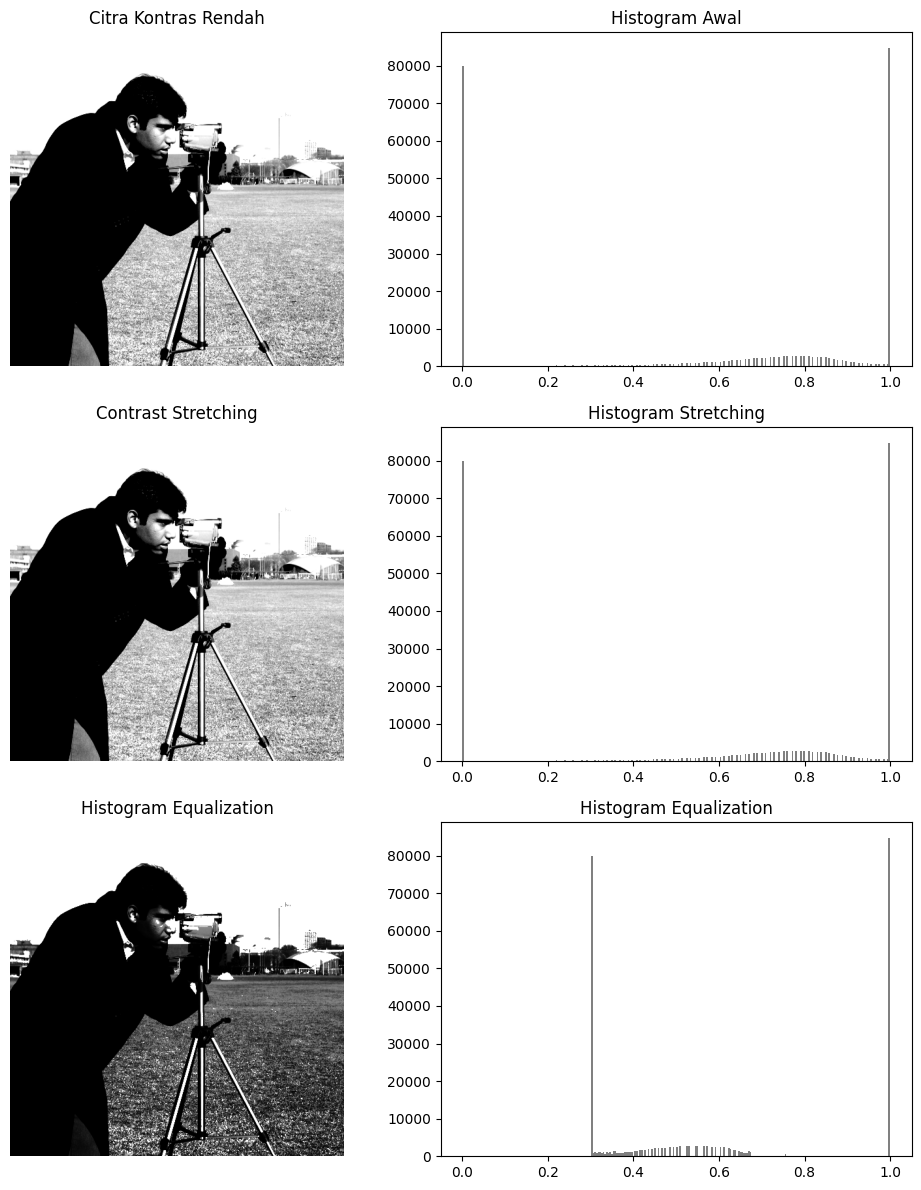

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, exposure, img_as_float

# =========================
# 1. Ambil citra grayscale
# =========================
image = img_as_float(data.camera())

# Simulasi citra kontras rendah (biar lebih terlihat efeknya)
low_contrast = exposure.rescale_intensity(image, in_range=(0.3, 0.7))

# =========================
# 2. Contrast Stretching
# =========================
stretch = exposure.rescale_intensity(low_contrast)

# =========================
# 3. Histogram Equalization
# =========================
equalized = exposure.equalize_hist(low_contrast)

# =========================
# 4. Visualisasi gambar
# =========================
fig, axes = plt.subplots(3, 2, figsize=(10, 12))

# --- Citra ---
axes[0, 0].imshow(low_contrast, cmap='gray')
axes[0, 0].set_title("Citra Kontras Rendah")
axes[0, 0].axis('off')

axes[1, 0].imshow(stretch, cmap='gray')
axes[1, 0].set_title("Contrast Stretching")
axes[1, 0].axis('off')

axes[2, 0].imshow(equalized, cmap='gray')
axes[2, 0].set_title("Histogram Equalization")
axes[2, 0].axis('off')

# --- Histogram ---
axes[0, 1].hist(low_contrast.ravel(), bins=256, range=(0,1), color='gray')
axes[0, 1].set_title("Histogram Awal")

axes[1, 1].hist(stretch.ravel(), bins=256, range=(0,1), color='gray')
axes[1, 1].set_title("Histogram Stretching")

axes[2, 1].hist(equalized.ravel(), bins=256, range=(0,1), color='gray')
axes[2, 1].set_title("Histogram Equalization")

plt.tight_layout()
plt.show()

##**Penugasan Nomor 5**
Soal :

5.	Filter Median vs Filter Rata-rata: Uji kinerja filter median dibandingkan filter rata-rata dalam mengatasi derau. Tambahkan noise salt-and-pepper pada sebuah citra grayscale (gunakan fungsi util.random_noise). Kemudian, saring citra berderau tersebut dengan filter rata-rata (dapat menggunakan konvolusi kernel ones atau filters.gaussian untuk smoothing Gaussian) dan dengan filter median. Tampilkan hasil kedua filter dan bandingkan. Fokus pada perbedaan di tepi objek dan sisa noise yang mungkin ada. Jelaskan mengapa salah satu filter lebih unggul dari yang lain untuk kasus noise impuls.
https://scikit-image.org/docs/stable/api/skimage.util.html#skimage.util.random_noise


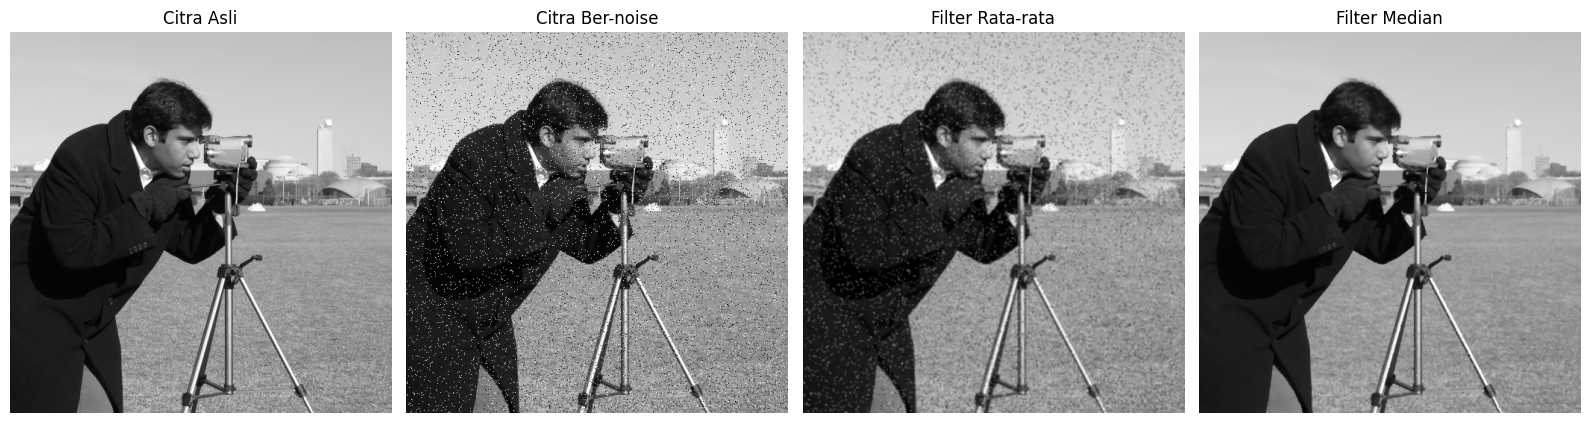

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, util, filters, img_as_float
from scipy.ndimage import convolve

# =========================
# 1. Ambil citra grayscale
# =========================
image = img_as_float(data.camera())

# =========================
# 2. Tambahkan noise salt & pepper
# =========================
noisy = util.random_noise(image, mode='s&p', amount=0.05)

# =========================
# 3. Filter rata-rata (mean filter)
# =========================
kernel = np.ones((3,3)) / 9
mean_filtered = convolve(noisy, kernel)

# =========================
# 4. Filter median
# =========================
median_filtered = filters.median(noisy)

# =========================
# 5. Visualisasi
# =========================
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

axes[0].imshow(image, cmap='gray')
axes[0].set_title("Citra Asli")
axes[0].axis('off')

axes[1].imshow(noisy, cmap='gray')
axes[1].set_title("Citra Ber-noise")
axes[1].axis('off')

axes[2].imshow(mean_filtered, cmap='gray')
axes[2].set_title("Filter Rata-rata")
axes[2].axis('off')

axes[3].imshow(median_filtered, cmap='gray')
axes[3].set_title("Filter Median")
axes[3].axis('off')

plt.tight_layout()
plt.show()